In [1]:
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


In [2]:

plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.size'] = 18
fontfam = 'sans-serif'
plt.rcParams['font.family'] = fontfam
plt.rcParams[f'font.{fontfam}'] = ['arial', *plt.rcParams[f'font.{fontfam}']]
plt.rcParams['lines.markersize'] = 18
plt.rcParams['lines.markeredgewidth'] = 3

plot_properties_yaml = "../../results/figures/plot_properties.yaml"
# Load plot properties
with open(plot_properties_yaml) as prop_yaml:
    plot_props = yaml.safe_load(prop_yaml)

positions = plot_props["positions"]
r_column = plot_props["d_column"] / 2


In [3]:

# Load experiment database
exp_h5 = pd.HDFStore("../../data/02_processed/per-experiment-data.h5")
exp_df = exp_h5['data']
exp_h5.close()


In [4]:
png_path = Path("../../results/figures/poster/png")
svg_path = Path("../../results/figures/poster/svg")
eps_path = Path("../../results/figures/poster/eps")

png_path.mkdir(exist_ok=True, parents=True)
svg_path.mkdir(exist_ok=True, parents=True)
eps_path.mkdir(exist_ok=True, parents=True)

In [5]:
# Holdups: profile for high salt and profile for water.
water_df = exp_df.loc[exp_df["Salt"] == "Water"]
na2so4_df = exp_df.loc[(exp_df["Salt"] == "Na2SO4") & (exp_df["Concentration (mol/l)"] == 0.5)]

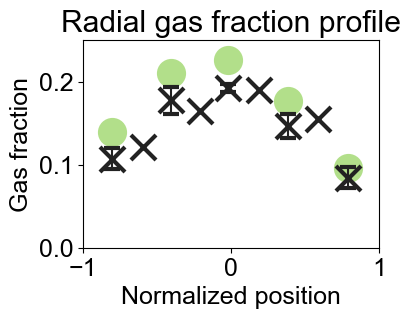

In [6]:
hu_fig, ax = plt.subplots(1, 1, layout="constrained", figsize=(10/2.6, 8/2.6))

# Assuming water_df has multiple rows, each with lists in 'FP Positions' and 'Holdup FP (meas)'
# Flatten the data to get all position-holdup pairs across experiments
positions_all = []
holdups_all = []
pos_list = water_df.iloc[0].loc['FP Positions']
holdup_list = water_df.iloc[0].loc['Holdup FP (meas)']
positions_all.extend(pos_list)
holdups_all.extend(holdup_list)

# Create a DataFrame for grouping
flat_df = pd.DataFrame({'position': positions_all, 'holdup': holdups_all})

# Group by position and compute mean and std
grouped = flat_df.groupby('position')['holdup'].agg(['mean', 'std']).reset_index()

# Plot with errorbar
ax.plot(na2so4_df['FP Positions'].iloc[0], na2so4_df['Holdup FP (meas)'].iloc[0], 'o', label='Na2SO4', color=plot_props['salt_colors']['Na2SO4'])
ax.errorbar(grouped['position'], grouped['mean'], yerr=grouped['std'], fmt='x', label='Water', capsize=6, color=plot_props['salt_colors']['Water'])
ax.set_xlabel("Normalized position")
ax.set_ylabel("Gas fraction")
ax.set_title("Radial gas fraction profile")
ax.set_ylim(0, 0.25)
ax.set_xlim(-1, 1)

hu_fig.savefig(png_path / "FP_holdup.png", bbox_inches='tight', dpi=900)
hu_fig.savefig(svg_path / "FP_holdup.svg")
hu_fig.savefig(eps_path / "FP_holdup.eps")


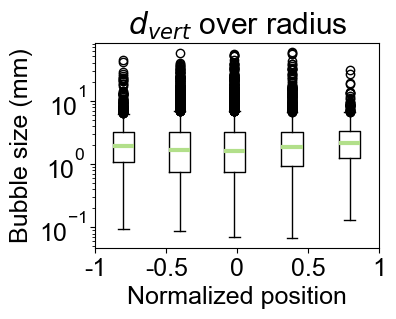

In [7]:
# BSD over radius - boxplots (na2so4 only)
bsd_fig, ax = plt.subplots(1, 1, layout="constrained", figsize=(10/2.6, 8/2.6))
bsd = na2so4_df['BSD'].iloc[0]/1000
ax.boxplot(na2so4_df['BSD'].iloc[0]/1000,
           positions=na2so4_df['FP Positions'].iloc[0],
           widths=0.15,
           medianprops={'color': plot_props['salt_colors']['Na2SO4'], 'linewidth': 3},
           )
ax.set_yscale('log')
ax.set_ylabel("Bubble size (mm)")
ax.set_xlabel("Normalized position")
ax.set_title("$d_{vert}$ over radius")
ax.set_xticks([-1, -0.5, 0, 0.5, 1])
ax.set_xticklabels([-1, -0.5, 0, 0.5, 1])
ax.set_xlim(-1, 1)

bsd_fig.savefig(png_path / "FP_bsd_boxplot.png", bbox_inches='tight', dpi=900)
bsd_fig.savefig(svg_path / "FP_bsd_boxplot.svg")
bsd_fig.savefig(eps_path / "FP_bsd_boxplot.eps")

In [21]:
def d_B_step(r_R, d_B, rel_pos):
    """return d_B for rel_pos closest to r_R

    Args:
        r_R (float or np.ndarray): Relative position(s) to get d_B for
        d_B (np.ndarray): Bubble sizes corresponding to rel_pos
        rel_pos (np.ndarray): Relative positions corresponding to BSD measurements

    Returns:
        float or np.ndarray: Bubble sizes corresponding to r_R
    """
    assert len(d_B) == len(rel_pos), "len(d_B) =/= len(rel_pos)"
    d_B = np.array(d_B)
    rel_pos = np.array(rel_pos)
    
    crosses = rel_pos[:-1] + np.abs(rel_pos[1:] - rel_pos[:-1]) / 2
    crosses = [-1, *crosses, 1]
    # find i where crosses[i-1] < r_R
    i = np.searchsorted(crosses, r_R)
    # corresponds to d_median[i-1], but avoid negative values
    d_i = np.where(i-1 < 0, 0, i-1)
    return d_B[d_i]


In [18]:
na2so4_df['FP Positions'].iloc[0]

AttributeError: 'numpy.ndarray' object has no attribute 'unique'

[-0.80208333 -0.59375    -0.40625    -0.20833333 -0.02083333  0.1875
  0.38541667  0.58333333  0.79166667]
[0.71067933 0.6220148  0.46327702 0.51702622 0.41932302 0.38320285
 0.5129296  0.55597264 0.80198055]


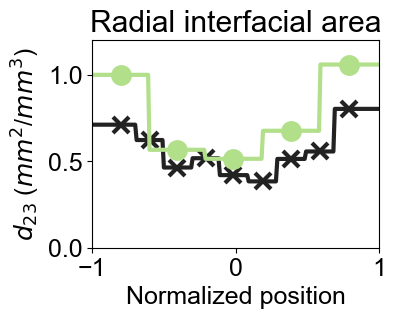

In [34]:
# D23 over radius - points and block-representation for integration
with plt.rc_context({"lines.markersize": 12}):
    d23_fig, ax = plt.subplots(1, 1, layout="constrained", figsize=(10/2.6, 8/2.6))
    # Water
    positions = np.unique(water_df['FP Positions'].iloc[0])
    d23_vals = water_df['d23 - Q1-Q99'].iloc[0][0] * 1000
    plot_positions = np.arange(-1, 1, .01)

    d23_continuous = d_B_step(plot_positions, d23_vals, positions)

    ax.plot(plot_positions, d23_continuous, color=plot_props['salt_colors']['Water'], lw=3)
    ax.plot(positions, d23_vals, 'x', color=plot_props['salt_colors']['Water'])

    # Na2SO4
    positions = np.unique(na2so4_df['FP Positions'].iloc[0])
    d23_vals = na2so4_df['d23 - Q1-Q99'].iloc[0][0] * 1000
    plot_positions = np.arange(-1, 1, .01)

    d23_continuous = d_B_step(plot_positions, d23_vals, positions)

    plot_positions.shape, d23_continuous
    ax.plot(plot_positions, d23_continuous, color=plot_props['salt_colors']['Na2SO4'], lw=3)
    ax.plot(positions, d23_vals, 'o', color=plot_props['salt_colors']['Na2SO4'])

    ax.set_xlim(-1, 1)
    ax.set_ylim(0, 1.2)

    ax.set_ylabel("$d_{23}$ ($mm^2$/$mm^3$)")
    ax.set_xlabel("Normalized position")
    ax.set_title("Radial interfacial area")
    
    d23_fig.savefig(png_path / "FP_d23.png", bbox_inches='tight', dpi=900)
    d23_fig.savefig(svg_path / "FP_d23.svg")
    d23_fig.savefig(eps_path / "FP_d23.eps")

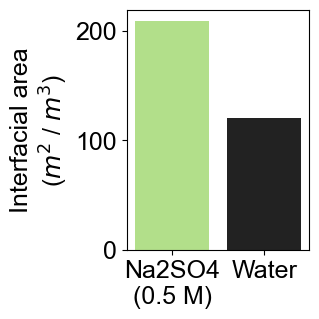

In [50]:
ia_fig, ax = plt.subplots(1, 1, layout="constrained", figsize=(8/2.6, 8/2.6))

ia_na2so4 = na2so4_df['Interfacial area (m2/m3)'].iloc[0]
ia_water = water_df['Interfacial area (m2/m3)'].iloc[0]
labels = ['Na2SO4\n(0.5 M)', 'Water']

bars = ax.bar(labels, [ia_na2so4, ia_water], color=[plot_props['salt_colors']['Na2SO4'], plot_props['salt_colors']['Water']])
# bars[0].fill = plot_props['salt_colors']['Na2SO4']
# bars[1].fill = plot_props['salt_colors']['Water']
ax.set_ylabel("Interfacial area\n($m^2$ / $m^3$)")

ia_fig.savefig(png_path / "FP_ia.png", bbox_inches='tight', dpi=900)
ia_fig.savefig(svg_path / "FP_ia.svg")
ia_fig.savefig(eps_path / "FP_ia.eps")